# Metabolic History and DM Medication Initiation
Which patients had baseline DM, which ones were started on DM meds (which agents were they on? Any stats significant differences here and illustrate)

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm


seed = 42
n_folds = 5
df1 = pd.read_csv('../../data/processed/cardio_onc_prostate_06_broad_clean.csv')

## Data

In [2]:
# Drop missing outcome
df = df1[df1["dm_meds_post"].notna()].copy()

# Binary recoding
df["hx_dm2_bin"] = (df["hx_dm2"] == 1).astype(int)
df["dm_meds_post_bin"] = (df["dm_meds_post"] > 0).astype(int)
df["on_insulin_bin"] = (df["on_insulin"] == 1).astype(int)

# Drop missing outcome
df = df[df["dm_meds_post"].notna()].copy()

# Outcome (binary)
df["dm_meds_post_bin"] = (df["dm_meds_post"] > 0).astype(int)

# clean ADT
df["adt_clean"] = (
    df["adt_agent"]
    .astype(str)
    .str.lower()
    .str.strip()
    .replace({"lupon": "lupron", "lpron": "lupron"})
)

main_adt_agents = ["lupron", "firmagon", "orgovyx", "bicalutamide"]

def extract_main_adt(text):
    for agent in main_adt_agents:
        if agent in str(text):
            return agent
    return "other"

df["adt_grouped"] = df["adt_clean"].apply(extract_main_adt)


print(df.shape)

(202, 65)


In [3]:
features = [
    "hx_dm2",          # baseline diabetes
    "a1c_checked",
    "glucose_over_200",
    "dm_noninsulin",   # baseline meds
    "on_insulin"
]

X = df[features].copy()
y = df["dm_meds_post"].astype(int)

print(X.isna().sum())
print(y.value_counts())

hx_dm2              2
a1c_checked         1
glucose_over_200    1
dm_noninsulin       1
on_insulin          3
dtype: int64
dm_meds_post
0    161
2     25
1     16
Name: count, dtype: int64


## Which patients had baseline DM?

In [4]:
# cohorts
dm_df = df[df["dm_meds_post_bin"] == 1].copy() #patients who start DM meds

dm_baseline = df[df["hx_dm2"] == 1].copy() # patients with baseline DM
no_dm_baseline = df[df["hx_dm2"] == 0].copy() # patients without baseline DM

In [5]:
df["hx_dm2_bin"] = (df["hx_dm2"] == 1).astype(int)

n_total = len(df)
n_dm = df["hx_dm2_bin"].sum()

print(f"Baseline DM: {n_dm}/{n_total} ({n_dm/n_total:.1%})")

Baseline DM: 60/202 (29.7%)


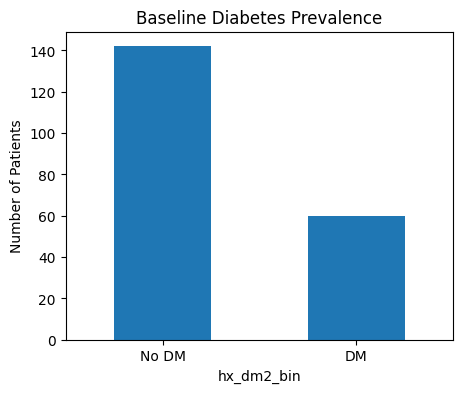

In [6]:
plt.figure(figsize=(5,4))

df["hx_dm2_bin"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xticks([0,1], ["No DM", "DM"], rotation=0)
plt.title("Baseline Diabetes Prevalence")
plt.ylabel("Number of Patients")
plt.show()

### Summary
Among the cohort of interest, a subset of patients had a documented history of type 2 diabetes mellitus prior to initiation of novel hormonal therapy (NHT). Baseline diabetes was present in 29.7% of patients (n = 60 / 202) with data on whether or not they started new DM medications after NHT initiation, indicating a clinically relevant burden of metabolic disease within this population.

## DM medication initiation demographics

In [7]:
demo_vars_cont = ["age", "bmi"]

df.groupby("dm_meds_post_bin")[demo_vars_cont].agg(["mean", "std"])

age                  bmi          
                       mean       std       mean       std
dm_meds_post_bin                                          
0                 71.931250  8.990646  27.585625  5.044465
1                 70.243902  9.079594  28.164500  5.722778

In [8]:
demo_vars_cat = ["ethnicity", "hx_smoking", "has_pcp"]

for col in demo_vars_cat:
    print("\n", col)
    print(pd.crosstab(df[col], df["dm_meds_post_bin"], normalize="columns"))


 ethnicity
dm_meds_post_bin         0         1
ethnicity                           
Asian             0.133758  0.146341
Black             0.089172  0.073171
Caucasian         0.573248  0.463415
Hispanic          0.114650  0.097561
Other             0.089172  0.219512

 hx_smoking
dm_meds_post_bin         0         1
hx_smoking                          
0.0               0.652174  0.634146
1.0               0.304348  0.292683
2.0               0.043478  0.073171

 has_pcp
dm_meds_post_bin    0         1
has_pcp                        
0.0               0.1  0.219512
1.0               0.9  0.780488


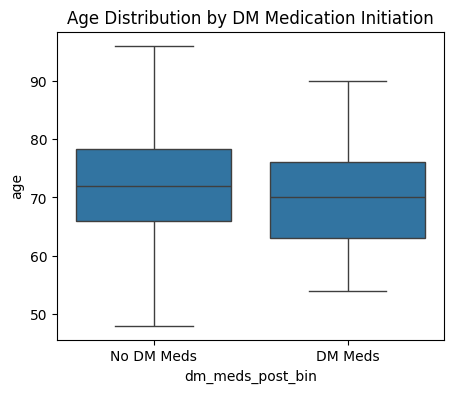

In [9]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="dm_meds_post_bin", y="age")

plt.xticks([0,1], ["No DM Meds", "DM Meds"])
plt.title("Age Distribution by DM Medication Initiation")
plt.show()

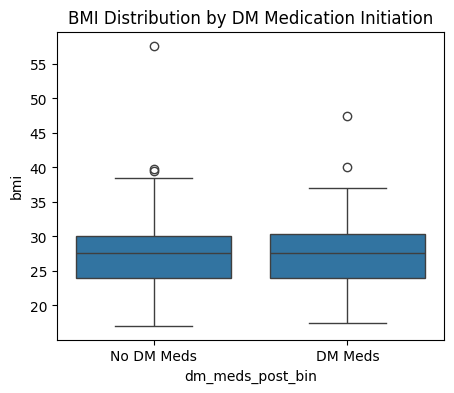

In [10]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="dm_meds_post_bin", y="bmi")

plt.xticks([0,1], ["No DM Meds", "DM Meds"])
plt.title("BMI Distribution by DM Medication Initiation")
plt.show()

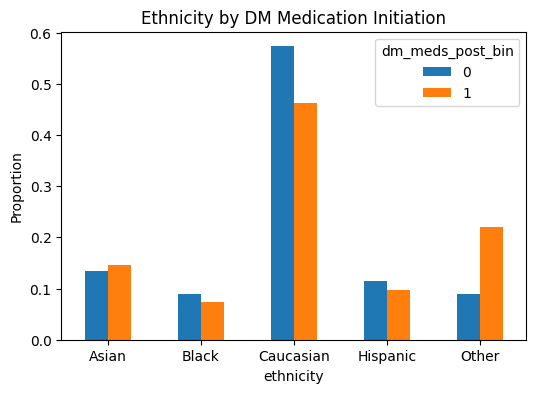

In [11]:
eth_table = pd.crosstab(df["ethnicity"], df["dm_meds_post_bin"], normalize="columns")

eth_table.plot(kind="bar", figsize=(6,4))

plt.title("Ethnicity by DM Medication Initiation")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

## Which patients started on DM meds?

In [12]:
df["dm_meds_post_bin"] = (df["dm_meds_post"] > 0).astype(int)

print(df["dm_meds_post_bin"].value_counts(normalize=True))

# By baseline DM
ct = pd.crosstab(df["hx_dm2_bin"], df["dm_meds_post_bin"])
print(ct)

ct_prop = ct.div(ct.sum(axis=1), axis=0)
print(ct_prop)

dm_meds_post_bin
0    0.79703
1    0.20297
Name: proportion, dtype: float64
dm_meds_post_bin    0   1
hx_dm2_bin               
0                 121  21
1                  40  20
dm_meds_post_bin         0         1
hx_dm2_bin                          
0                 0.852113  0.147887
1                 0.666667  0.333333


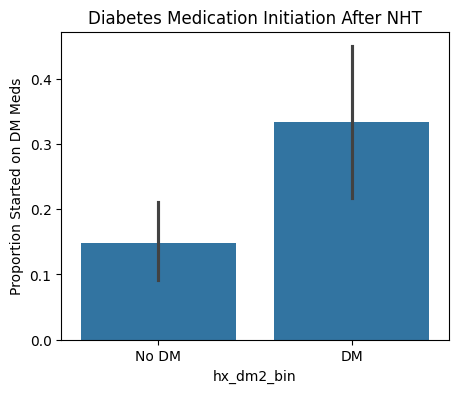

In [13]:
plt.figure(figsize=(5,4))

sns.barplot(
    data=df,
    x="hx_dm2_bin",
    y="dm_meds_post_bin"
)

plt.xticks([0,1], ["No DM", "DM"])
plt.title("Diabetes Medication Initiation After NHT")
plt.ylabel("Proportion Started on DM Meds")
plt.show()

### Summary
Following NHT initiation, 20.29% of patients were started on one or more new diabetes medications (dm_meds_post > 0). Patients with baseline diabetes were substantially more likely to initiate diabetes therapy compared to those without diabetes.

The proportion of medication initiation was higher among patients with pre-existing diabetes (33.3% vs 14.78%), suggesting that baseline metabolic disease strongly influences post-NHT glycemic management.

## Any statistically significant differences?

In [14]:
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi-square statistic:", chi2)
print(f"p-value: {p:.4f}")
print("degrees of freedom:", dof)

Chi-square statistic: 7.856667790411611
p-value: 0.0051
degrees of freedom: 1


### Summary
There was a statistically significant association between baseline diabetes status and initiation of diabetes medications after NHT (0.0051 < 0.05).

This indicates that patients with pre-existing metabolic disease were more likely to require pharmacologic escalation following NHT exposure.

## For patients that started on DM meds, which agents were they on?
NHT agents refer to androgen receptor pathway inhibitors (Abiraterone, Enzalutamide, Apalutamide, Darolutamide), and ADT agents refer to androgen deprivation therapies (Lupron, Firmagon, Orgovyx, Bicalutamide).

In [15]:
# only patients who started on DM meds
dm_df = df[df["dm_meds_post_bin"] == 1].copy()
non_dm_df = df[df["dm_meds_post_bin"] == 0].copy()

### NHT

In [16]:
# NHT
nht_counts_dm = dm_df["specific_nht_used"].value_counts(normalize=True)
nht_counts_non_dm = non_dm_df["specific_nht_used"].value_counts(normalize=True)
nht_counts_total = df["specific_nht_used"].value_counts(normalize=True)

nht_compare = pd.concat(
    [nht_counts_total, nht_counts_dm, nht_counts_non_dm],
    axis=1
)

nht_compare.columns = ["Overall", "DM Meds Started", "No DM Meds Started"]

# Fill missing categories
nht_compare = nht_compare.fillna(0)

# Add difference column (key insight)
nht_compare["Difference (DM - No DM Meds)"] = (
    nht_compare["DM Meds Started"] - nht_compare["No DM Meds Started"]
)

print(nht_compare.sort_values("Difference (DM - No DM Meds)", ascending=False))

                    Overall  DM Meds Started  No DM Meds Started  \
specific_nht_used                                                  
Abiraterone        0.435644         0.487805            0.422360   
Darolutamide       0.405941         0.414634            0.403727   
Enzalutamide       0.094059         0.073171            0.099379   
Apalutamide        0.064356         0.024390            0.074534   

                   Difference (DM - No DM Meds)  
specific_nht_used                                
Abiraterone                            0.065445  
Darolutamide                           0.010907  
Enzalutamide                          -0.026208  
Apalutamide                           -0.050144  


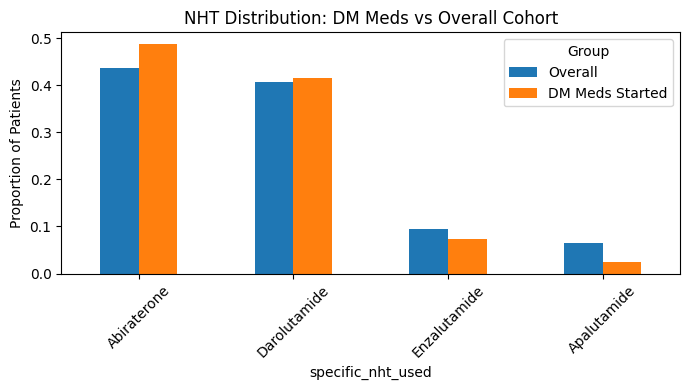

In [17]:
adt_compare = pd.concat(
    [
        df["specific_nht_used"].value_counts(normalize=True),
        dm_df["specific_nht_used"].value_counts(normalize=True)
    ],
    axis=1
)

adt_compare.columns = ["Overall", "DM Meds Started"]
adt_compare = adt_compare.fillna(0)

adt_compare.plot(kind="bar", figsize=(7,4))

plt.title("NHT Distribution: DM Meds vs Overall Cohort")
plt.ylabel("Proportion of Patients")
plt.xticks(rotation=45)
plt.legend(title="Group")
plt.tight_layout()
plt.show()

### ADT

In [18]:
# ADT
nht_counts_dm = dm_df["adt_grouped"].value_counts(normalize=True)
nht_counts_non_dm = non_dm_df["adt_grouped"].value_counts(normalize=True)
nht_counts_total = df["adt_grouped"].value_counts(normalize=True)

nht_compare = pd.concat(
    [nht_counts_total, nht_counts_dm, nht_counts_non_dm],
    axis=1
)

nht_compare.columns = ["Overall", "DM Meds Started", "No DM Meds Started"]

# Fill missing categories
nht_compare = nht_compare.fillna(0)

# Add difference column (key insight)
nht_compare["Difference (DM - No DM Meds)"] = (
    nht_compare["DM Meds Started"] - nht_compare["No DM Meds Started"]
)

print(nht_compare.sort_values("Difference (DM - No DM Meds)", ascending=False))

               Overall  DM Meds Started  No DM Meds Started  \
adt_grouped                                                   
firmagon      0.089109         0.146341            0.074534   
other         0.059406         0.073171            0.055901   
bicalutamide  0.133663         0.146341            0.130435   
orgovyx       0.396040         0.365854            0.403727   
lupron        0.321782         0.268293            0.335404   

              Difference (DM - No DM Meds)  
adt_grouped                                 
firmagon                          0.071807  
other                             0.017270  
bicalutamide                      0.015907  
orgovyx                          -0.037873  
lupron                           -0.067111  


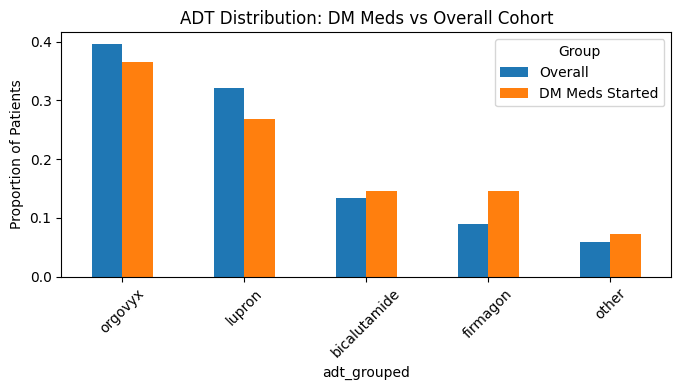

In [19]:
adt_compare = pd.concat(
    [
        df["adt_grouped"].value_counts(normalize=True),
        dm_df["adt_grouped"].value_counts(normalize=True)
    ],
    axis=1
)

adt_compare.columns = ["Overall", "DM Meds Started"]
adt_compare = adt_compare.fillna(0)

adt_compare.plot(kind="bar", figsize=(7,4))

plt.title("ADT Distribution: DM Meds vs Overall Cohort")
plt.ylabel("Proportion of Patients")
plt.xticks(rotation=45)
plt.legend(title="Group")
plt.tight_layout()
plt.show()

In [20]:
ct_adt = pd.crosstab(df["specific_nht_used"], df["dm_meds_post_bin"], normalize="index")

print(ct_adt)

ct_adt = pd.crosstab(df["adt_grouped"], df["dm_meds_post_bin"], normalize="index")

print(ct_adt)

dm_meds_post_bin          0         1
specific_nht_used                    
Abiraterone        0.772727  0.227273
Apalutamide        0.923077  0.076923
Darolutamide       0.792683  0.207317
Enzalutamide       0.842105  0.157895
dm_meds_post_bin         0         1
adt_grouped                         
bicalutamide      0.777778  0.222222
firmagon          0.666667  0.333333
lupron            0.830769  0.169231
orgovyx           0.812500  0.187500
other             0.750000  0.250000


In [21]:
ct = pd.crosstab(df["specific_nht_used"], df["dm_meds_post_bin"])
chi2, p, _, _ = chi2_contingency(ct)

print(f"NHT agent vs DM meds p-value: {p:.4f}")

NHT agent vs DM meds p-value: 0.6049


In [22]:
ct = pd.crosstab(df["adt_grouped"], df["dm_meds_post_bin"])
chi2, p, _, _ = chi2_contingency(ct)

print(f"ADT agent vs DM meds p-value: {p:.4f}")

ADT agent vs DM meds p-value: 0.6105


# Overall Summary: 

Across both ADT and NHT agent comparisons, no clinically meaningful differences were observed between patients who initiated diabetes medications and those who did not. Distributional differences across treatment groups were consistently small (absolute differences <10%), and statistical testing did not demonstrate a robust association after clinically appropriate grouping of agents.

Although ungrouped analyses of ADT agents suggested a borderline association, this signal was not preserved after collapsing agents into clinically meaningful categories, indicating that initial variation was likely driven by sparse or heterogeneous treatment combinations rather than true pharmacologic effects.

Overall, these findings suggest that DM medication initiation following NHT is more strongly associated with baseline metabolic risk factors rather than specific androgen deprivation or hormonal therapy selection.

## Logistic Regression Model
Which factors are associated with the initiation of DM medication after NHT?

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.4610447663973763
            Iterations: 73
            Function evaluations: 73
            Gradient evaluations: 73
                           Logit Regression Results                           
Dep. Variable:       dm_meds_post_bin   No. Observations:                  202
Model:                          Logit   Df Residuals:                      191
Method:                           MLE   Df Model:                           10
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.08612
Time:                        16:33:42   Log-Likelihood:                -93.131
converged:                       True   LL-Null:                       -101.91
Covariance Type:            nonrobust   LLR p-value:                   0.06299
                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------

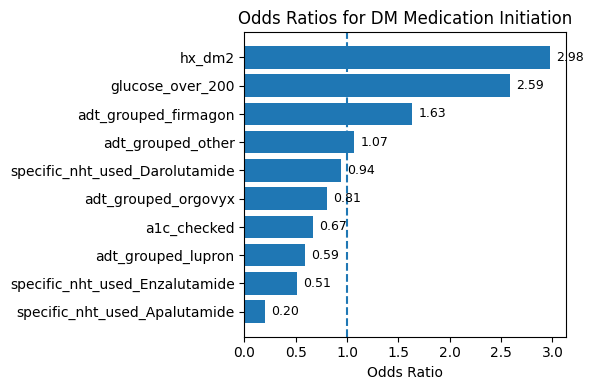

In [31]:
# Features
features = [
    "hx_dm2",
    "glucose_over_200",
    "a1c_checked",
    "specific_nht_used",
    "adt_grouped"
]

X = df[features].copy()
y = df["dm_meds_post_bin"]

# Binary recoding
X["hx_dm2"] = (X["hx_dm2"] == 1).astype(int)
X["glucose_over_200"] = (X["glucose_over_200"] == 1).astype(int)
X["a1c_checked"] = (X["a1c_checked"] == 1).astype(int)

# one hot encode
X = pd.get_dummies(
    X,
    columns=["specific_nht_used", "adt_grouped"],
    drop_first=True
)

# remove sparse features
min_count = 5
X = X.loc[:, X.sum() >= min_count]

# Ensure numeric
X = X.astype(float)

# fit logistic regression
X_sm = sm.add_constant(X)
y = y.loc[X_sm.index]

model = sm.Logit(y, X_sm)

# Use regularized fit
result = model.fit_regularized()

print(result.summary())

# odds ratio
summary_df = pd.DataFrame({
    "feature": result.params.index,
    "coef": result.params.values,
    "odds_ratio": np.exp(result.params.values)
})

print(summary_df.sort_values("odds_ratio", ascending=False))

# viz
# viz
plot_df = summary_df[summary_df["feature"] != "const"].copy()

# sort from lowest to highest odds ratio
plot_df = plot_df.sort_values("odds_ratio", ascending=True)

plt.figure(figsize=(6,4))
bars = plt.barh(plot_df["feature"], plot_df["odds_ratio"])

# reference line at OR = 1
plt.axvline(1, linestyle="--")

# add labels on bars
for i, value in enumerate(plot_df["odds_ratio"]):
    offset = max(plot_df["odds_ratio"]) * 0.02  # consistent spacing
    plt.text(
        value + offset,
        i,
        f"{value:.2f}",
        va='center',
        fontsize=9
    )

plt.title("Odds Ratios for DM Medication Initiation")
plt.xlabel("Odds Ratio")
plt.tight_layout()
plt.show()

## Logistic Regression Interpretation

In the multivariable logistic regression model assessing predictors of diabetes medication initiation after NHT, baseline type 2 diabetes was the only statistically significant predictor (OR ≈ 3.0, p = 0.008), indicating substantially higher odds of requiring new diabetes therapy in patients with pre-existing DM. Elevated glucose (>200 mg/dL) showed a positive but non-significant association with medication initiation (p = 0.117), while A1C monitoring was not independently predictive. Neither NHT agent type nor ADT group was significantly associated with diabetes medication initiation, and most treatment-level coefficients were small and non-significant. Overall model performance was modest (pseudo R² ≈ 0.09; LLR p ≈ 0.063), suggesting that baseline metabolic risk, rather than specific hormonal therapy selection, was the primary driver of post-NHT diabetes medication escalation in this cohort.